### **We use the existing model for glacier mapping**
#### Training stategy analysis    
|training    |miou(%)|oa(%) |kappa |precision(%)|recall(%)|note|     
|----        |----   |----  |----  |  ----      |    -    |  - |     
|from scrath |93.66  |98.40 |0.9322|97.17       |96.21    |    |      
|finetuning 1|94.87  |98.88 |0.9451|98.16       |96.50    |    |     
|finetuning 2|95.16  |98.91 |0.9486|98.10       |96.86    |    |        


In [1]:
import glob
import torch
import numpy as np
import pandas as pd
import rasterio as rio
from notebooks import config
from utils.imgShow import imsShow
from utils.img2patch import img2patch
from utils.metrics import metrics_segm
from model import unet, u2net, u2net_timm


/home/xin/miniconda3/envs/glanet/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
paths_val_scene = config.paths_scene_val
paths_val_truth = config.paths_truth_val
# dir_result = 'data/result/u3net_cross_fusion/'
dir_result = 'data/result/finetuning/from_scratch/'
# paths_val_result = sorted(glob.glob('data/result/u3net_cross_fusion/*'))
paths_val_result = sorted(glob.glob(dir_result + '*.tif'))
print(len(config.paths_scene_val))  



13


In [3]:
## read data
scenes, results, truths = [], [], []
for path_scene, path_result, path_truth in zip(paths_val_scene, paths_val_result,  paths_val_truth):
    with rio.open(path_scene) as scene_rio:
        scene_arr = scene_rio.read()
        scene_arr = scene_arr.transpose((1, 2, 0))    ## (H,W,C)
        scenes.append(scene_arr)
    with rio.open(path_result) as result_rio:
        result_arr = result_rio.read(1)
        results.append(result_arr)
    with rio.open(path_truth) as truth_rio:
        truth_arr = truth_rio.read(1)                ## (H,W)
        profile_truth = truth_rio.profile
        truths.append(truth_arr)


/tmp/ipykernel_874417/4164364931.py:9: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  result_arr = result_rio.read(1)
/tmp/ipykernel_874417/4164364931.py:12: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  truth_arr = truth_rio.read(1)                ## (H,W)


In [4]:
metrics_scenes = {}
for i, (result_arr, truth_arr) in enumerate(zip(results, truths)):
    metrics_sg = metrics_segm(cla_map=result_arr, truth_map=truth_arr, 
                              class_labels=[0, 1], mean_mode=True)
    metrics = {'miou': metrics_sg.iou['labels_mean'], 
                'oa': metrics_sg.oa,
                'kappa': metrics_sg.kappa,
                # 'f1_score': metrics_sg.f1_score['labels_mean'],
                'precision': metrics_sg.precision['labels_mean'],
                'recall': metrics_sg.recall['labels_mean']}
    metrics_scenes[paths_val_truth[i].split('/')[-1].split('.')[0]] = metrics
len(metrics_scenes)    


13

In [5]:
df_metrics_scenes = pd.DataFrame.from_dict(metrics_scenes, orient='index')
df_metrics_scenes.loc['mean'] = df_metrics_scenes.mean(axis=0)
# weighted_avg = (df_metrics_scenes[['oa', 'f1_score', 'miou']].mul(df_metrics_scenes['weight'], axis=0).sum())
# df_metrics_scenes.loc['mean_weighted'] = weighted_avg
# df_metrics_scenes  
df_metrics_scenes.to_csv(dir_result + 'metrics_scenes.csv', index=True)
df_metrics_scenes 


,miou,oa,kappa,precision,recall
l5_scene_01,0.913404,0.976440,0.907523,0.935191,0.974969
l5_scene_06,0.908893,0.978190,0.902008,0.945019,0.957221
l5_scene_11,0.983993,0.992001,0.983862,0.991851,0.992013
l7_scene_03,0.956451,0.977800,0.955487,0.978597,0.977244
l7_scene_08,0.914343,0.957947,0.910337,0.949429,0.962491
l7_scene_13,0.949885,0.990430,0.947762,0.989766,0.959260
l8_scene_05,0.894201,0.991848,0.882733,0.985465,0.905101
l8_scene_10,0.939450,0.976687,0.937070,0.962333,0.975163
l9_scene_02,0.975370,0.997295,0.974816,0.995538,0.979576
l9_scene_07,0.875342,0.976843,0.861040,0.937233,0.924059


scene: l9_scene_07.tif, miou: 0.8753


array([<Axes: title={'center': 'input image'}>,
       <Axes: title={'center': 'prediction'}>,
       <Axes: title={'center': 'glacier truth'}>], dtype=object)

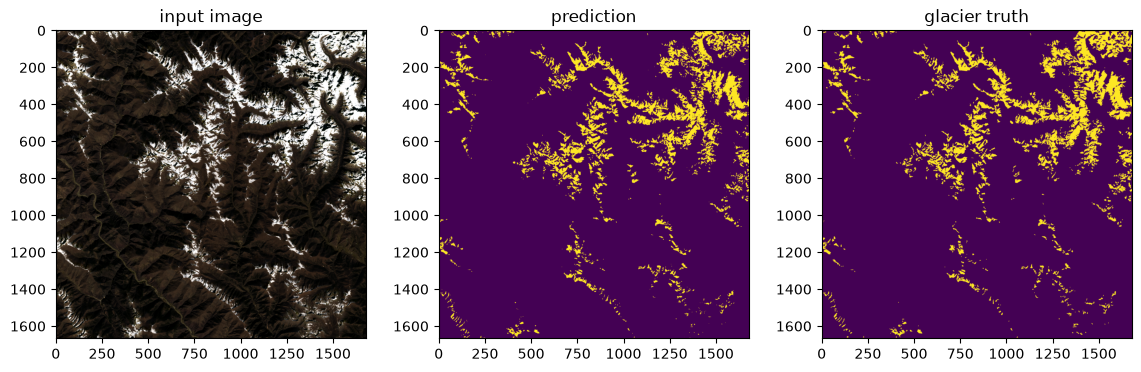

In [6]:
### show the results
i = 9
print(f'scene: {paths_val_scene[i].split("/")[-1]}, miou: {df_metrics_scenes.iloc[i]["miou"]:.4f}')
imsShow([scenes[i], results[i], truths[i]], 
        clip_list=[5, 0, 0], 
        img_name_list = ['input image', 'prediction', 'glacier truth'],
        figsize=(14, 4))
